# Draft vs. diameter sensitivity — hydrodynamic analysis

This notebook isolates the influence of **draft** and **diameter** on the OrcaWave
diffraction output of the Merganser float, using three runs that form a clean
one-factor-at-a-time (OFAT) design around a shared baseline:

| Run | File | Diameter | Draft |
|-----|------|----------|-------|
| baseline | `Merganser_3_V2.xlsx`    | 2.25 m | 3 m |
| deeper draft | `Merganser_4_V2.xlsx`    | 2.25 m | 4 m |
| larger diameter | `Merganser_3_D3_D3.xlsx` | 3.00 m | 3 m |

Two comparisons, each changing **one** parameter while holding the other fixed:

- **Draft effect** — diameter fixed at 2.25 m, draft 3 m → 4 m  (`Merganser_3_V2` vs `Merganser_4_V2`)
- **Diameter effect** — draft fixed at 3 m, diameter 2.25 m → 3.0 m  (`Merganser_3_V2` vs `Merganser_3_D3_D3`)

Because both comparisons pivot on the same baseline, the two effects can be read
on a common reference and compared directly (see the relative-influence view).

> **Caveat (natural periods).** The diffraction runs use placeholder inertia, so
> the displacement-RAO peaks below are *not* true natural periods — they shift
> only with hydrostatic stiffness and added mass, not with the real mass
> distribution. Treat them as indicative of the stiffness/added-mass trend, not
> as resonance periods.


## Imports and configuration

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
%matplotlib inline

plt.rcParams.update({
    "font.size": 13, "axes.titlesize": 16, "axes.labelsize": 14,
    "xtick.labelsize": 12, "ytick.labelsize": 12,
    "legend.fontsize": 11, "legend.title_fontsize": 12, "figure.titlesize": 19,
})

# =========================================================================
#  EDIT HERE - folder holding the three Merganser_*.xlsx files
# =========================================================================
CANDIDATE_DIRS = [
    Path(r"C:\Users\verav\Desktop\Studie\Afstuderen\Rhino\Draft sensitivity\XLSX_results"),
    Path("/mnt/user-data/uploads"),
    Path("."),
]
XLSX_DIR = next((d for d in CANDIDATE_DIRS
                 if (d / "Merganser_3_V2.xlsx").exists()), Path("."))
print("Reading from:", XLSX_DIR.resolve())

FIG_DIR = Path("DA_figures"); FIG_DIR.mkdir(exist_ok=True)

# -------------------------------------------------------------------------
#  Runs: file + geometry. Baseline is shared by both comparisons.
# -------------------------------------------------------------------------
RUNS = {
    "base":  dict(file="Merganser_3_V2.xlsx",    diameter=2.25, draft=3.0,
                  label="D 2.25 m, T 3 m  (baseline)"),
    "draft": dict(file="Merganser_4_V2.xlsx",    diameter=2.25, draft=4.0,
                  label="D 2.25 m, T 4 m"),
    "diam":  dict(file="Merganser_3_D3_D3.xlsx", diameter=3.00, draft=3.0,
                  label="D 3.0 m, T 3 m"),
}
for r in RUNS.values():
    r["path"] = XLSX_DIR / r["file"]

# Fixed colour per run, tied to the physical change it represents.
COLOR = {"base": "#555555", "draft": "#1f77b4", "diam": "#d62728"}

# The two one-factor-at-a-time comparisons. `members` ordered by increasing param.
EFFECTS = {
    "Draft": dict(members=["base", "draft"], key="draft",
                  unit="m", fixed="diameter = 2.25 m"),
    "Diameter": dict(members=["base", "diam"], key="diameter",
                     unit="m", fixed="draft = 3 m"),
}

# DOFs to plot. Value = 0-based diagonal index (Surge=0 .. Yaw=5).
DOFS = [("Heave", 2), ("Pitch", 4), ("Roll", 3)]
ROT_IDX = (3, 4, 5)
RAD2DEG = 180.0 / np.pi

# Load-RAO sheet: diffraction (direct) or Haskind (cross-check).
RAO_SHEET = "Load RAOs (diffraction)"

# Light vertical guides on the vs-period plots [s] (indicative period bands).
POI_LINES = [4.1, 8.4]


Reading from: C:\Users\verav\Desktop\Studie\Afstuderen\Rhino\Draft sensitivity\XLSX_results


## Readers

These are the same OrcaWave-export readers as in the draft-only notebook,
generalised to take a file path. Results are cached so each sheet is read once
per file. DOF order is Surge..Yaw throughout; NL decimal commas are handled.

In [2]:
from functools import lru_cache


@lru_cache(maxsize=None)
def read_matrix_sheet(xlsx, sheet):
    """'Added mass' / 'Damping' from one file. Returns (periods, diag[n, 6])."""
    df = pd.read_excel(xlsx, sheet_name=sheet, header=None)
    periods, diag = [], []
    for i in range(df.shape[0]):
        marker = df.iat[i, 1] if df.shape[1] > 1 else None
        if isinstance(marker, str) and "period" in marker.lower():
            txt = marker.lower().split("period")[-1].replace("s", "").strip()
            period = float(txt.replace(",", "."))            # NL comma -> dot
            block = df.iloc[i + 5: i + 11, 1:7].to_numpy(dtype=float)
            periods.append(period); diag.append(np.diag(block))
    order = np.argsort(periods)
    return np.array(periods)[order], np.array(diag)[order]


@lru_cache(maxsize=None)
def read_rao(xlsx, sheet):
    """Displacement or load RAOs for the single heading in the file.
    Returns (periods, ampl[n, 6], phase[n, 6]); DOF order Surge..Yaw."""
    df = pd.read_excel(xlsx, sheet_name=sheet, header=None)
    periods, ampl, phase = [], [], []
    for i in range(df.shape[0]):
        try:
            h = float(str(df.iat[i, 0]).replace(",", "."))   # wave heading
            T = float(str(df.iat[i, 1]).replace(",", "."))   # period
        except (ValueError, TypeError):
            continue
        if not (np.isfinite(h) and np.isfinite(T)):          # skip header rows
            continue
        a = [float(str(df.iat[i, 2 + 2 * k]).replace(",", ".")) for k in range(6)]
        p = [float(str(df.iat[i, 3 + 2 * k]).replace(",", ".")) for k in range(6)]
        periods.append(T); ampl.append(a); phase.append(p)
    order = np.argsort(periods)
    return np.array(periods)[order], np.array(ampl)[order], np.array(phase)[order]


@lru_cache(maxsize=None)
def read_hydrostatic_stiffness(xlsx, sheet="Hydrostatics"):
    """Diagonal of the 6x6 hydrostatic stiffness matrix from one file.
    Export units: translations kN/m, rotations kN.m/rad. DOF order Surge..Yaw."""
    df = pd.read_excel(xlsx, sheet_name=sheet, header=None)
    for i in range(df.shape[0]):
        marker = df.iat[i, 0] if df.shape[1] > 0 else None
        if isinstance(marker, str) and "hydrostatic stiffness" in marker.lower():
            return np.diag(df.iloc[i: i + 6, 1:7].to_numpy(dtype=float))
    raise ValueError(f"Hydrostatic stiffness matrix not found in {xlsx}")


# ---- One accessor that returns (periods, value[n, 6]) for any quantity --------
KINDS = {
    "added_mass": dict(label="Added mass",         ut="Added mass [t]",
                       ur="Added mass [t\u00b7m\u00b2]",            rot=1.0),
    "damping":    dict(label="Radiation damping",  ut="Damping [kN/(m/s)]",
                       ur="Damping [kN\u00b7m/(deg/s)]",           rot=RAD2DEG),
    "disp_rao":   dict(label="Displacement RAO",   ut="Displacement RAO [m/m]",
                       ur="Displacement RAO [deg/m]",              rot=RAD2DEG),
    "load_rao":   dict(label="Load RAO amplitude", ut="Load RAO [kN/m]",
                       ur="Load RAO [kN\u00b7m/m]",                rot=1.0),
}


def series(run_key, kind):
    """(periods, value[n, 6]) for a run and quantity, rotations already in deg."""
    path = str(RUNS[run_key]["path"])
    if kind == "added_mass":
        periods, val = read_matrix_sheet(path, "Added mass")
    elif kind == "damping":
        periods, val = read_matrix_sheet(path, "Damping")
    elif kind == "disp_rao":
        periods, val, _ = read_rao(path, "Displacement RAOs")
    elif kind == "load_rao":
        periods, val, _ = read_rao(path, RAO_SHEET)
    else:
        raise KeyError(kind)
    val = val.astype(float).copy()
    rot = KINDS[kind]["rot"]
    if rot != 1.0:
        val[:, list(ROT_IDX)] = val[:, list(ROT_IDX)] / rot   # per rad -> per deg
    return periods, val


def ylabel(kind, idx):
    return KINDS[kind]["ur"] if idx in ROT_IDX else KINDS[kind]["ut"]


# Quick sanity print: confirm every file reads and shares one period grid.
_grids = {k: series(k, "added_mass")[0] for k in RUNS}
_ref = _grids["base"]
_same = all(np.array_equal(_ref, g) for g in _grids.values())
print(f"Files read OK. Common period grid: {_same} "
      f"({len(_ref)} periods, {_ref.min():.1f}-{_ref.max():.1f} s)")


Files read OK. Common period grid: True (191 periods, 1.0-20.0 s)


## View A — output vs period, draft effect vs diameter effect

For each quantity the top row shows the **draft effect** (diameter fixed) and the
bottom row the **diameter effect** (draft fixed). The grey line is the shared
baseline in both rows, so the two parameters are read against a common reference.
Vertical guides mark indicative period bands.

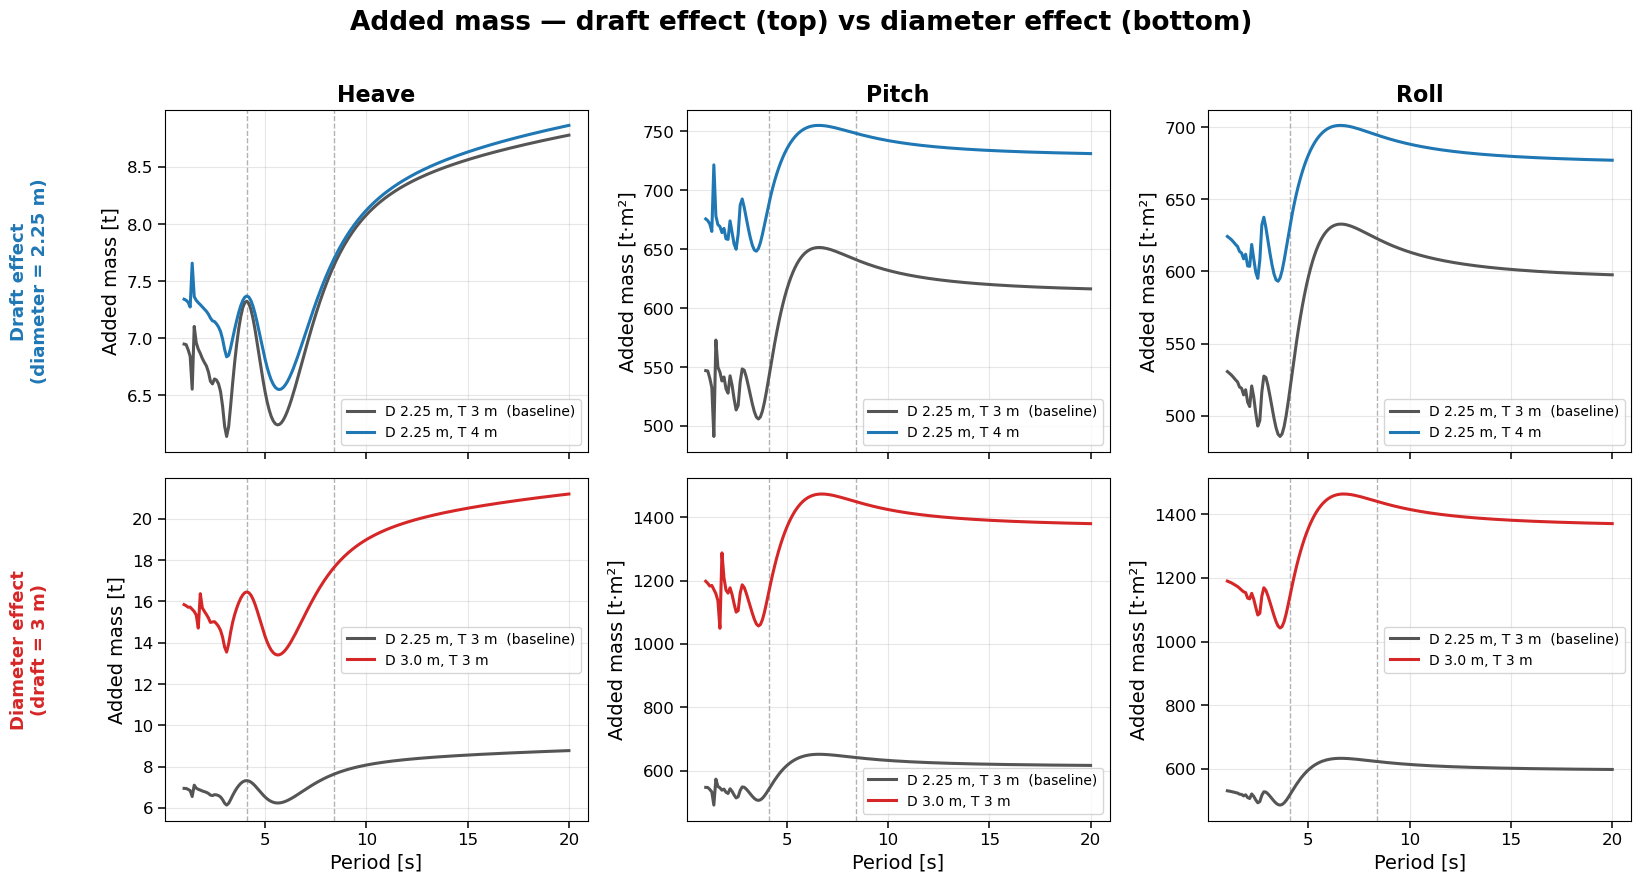

In [3]:
def plot_effect_grid(kind, fname=None):
    """2 rows (Draft effect, Diameter effect) x 3 DOFs, one line per run.
    Top row isolates draft (diameter fixed); bottom row isolates diameter."""
    klabel = KINDS[kind]["label"]
    fig, axes = plt.subplots(2, len(DOFS), figsize=(17, 9), sharex=True)

    for row, (eff_name, eff) in enumerate(EFFECTS.items()):
        for col, (dof_name, idx) in enumerate(DOFS):
            ax = axes[row, col]
            for rk in eff["members"]:
                periods, val = series(rk, kind)
                ax.plot(periods, val[:, idx], lw=2.2, color=COLOR[rk],
                        label=RUNS[rk]["label"])
            for T in POI_LINES:
                ax.axvline(T, color="0.5", ls="--", lw=1.0, alpha=0.6, zorder=0)
            if row == 0:
                ax.set_title(dof_name, fontweight="bold")
            if row == 1:
                ax.set_xlabel("Period [s]")
            ax.set_ylabel(ylabel(kind, idx))
            ax.grid(True, alpha=0.3)
            ax.tick_params(width=1.1, length=5)
            ax.legend(fontsize=10)
        # Row banner on the left-most axis.
        axes[row, 0].annotate(f"{eff_name} effect\n({eff['fixed']})",
                              xy=(-0.32, 0.5), xycoords="axes fraction",
                              rotation=90, va="center", ha="center",
                              fontweight="bold", fontsize=13, color=COLOR[eff["members"][1]])

    fig.suptitle(f"{klabel} — draft effect (top) vs diameter effect (bottom)",
                 fontweight="bold")
    fig.tight_layout(rect=[0.03, 0, 1, 0.97])
    if fname:
        fig.savefig(FIG_DIR / fname, dpi=150, bbox_inches="tight")
    return fig


fig = plot_effect_grid("added_mass", "A1_added_mass.png"); plt.show()


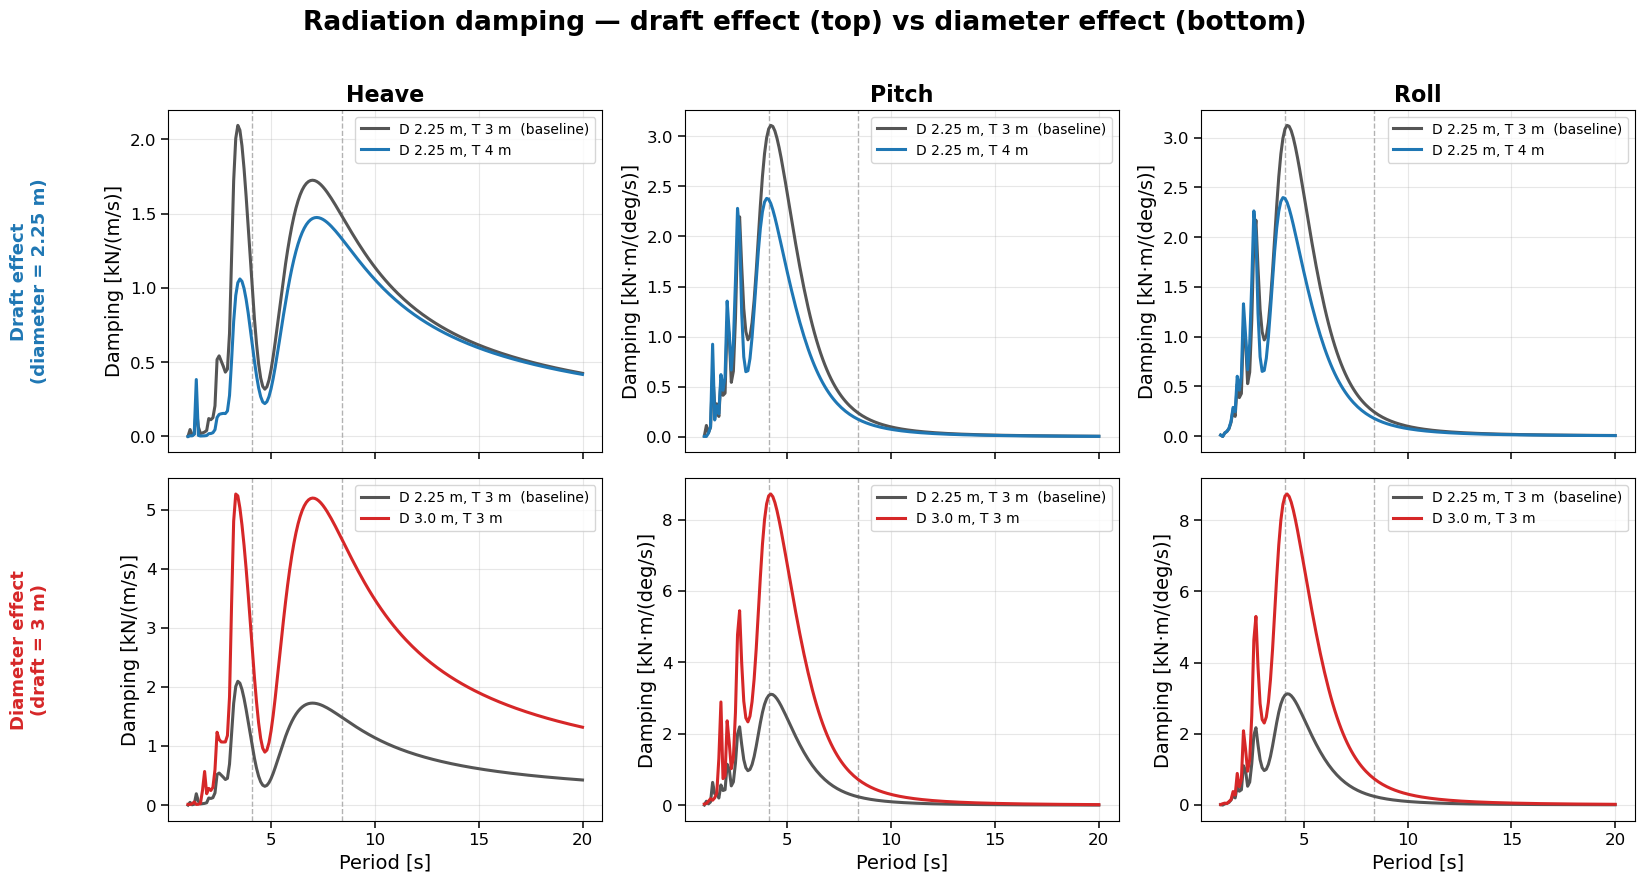

In [4]:
fig = plot_effect_grid("damping", "A2_damping.png"); plt.show()


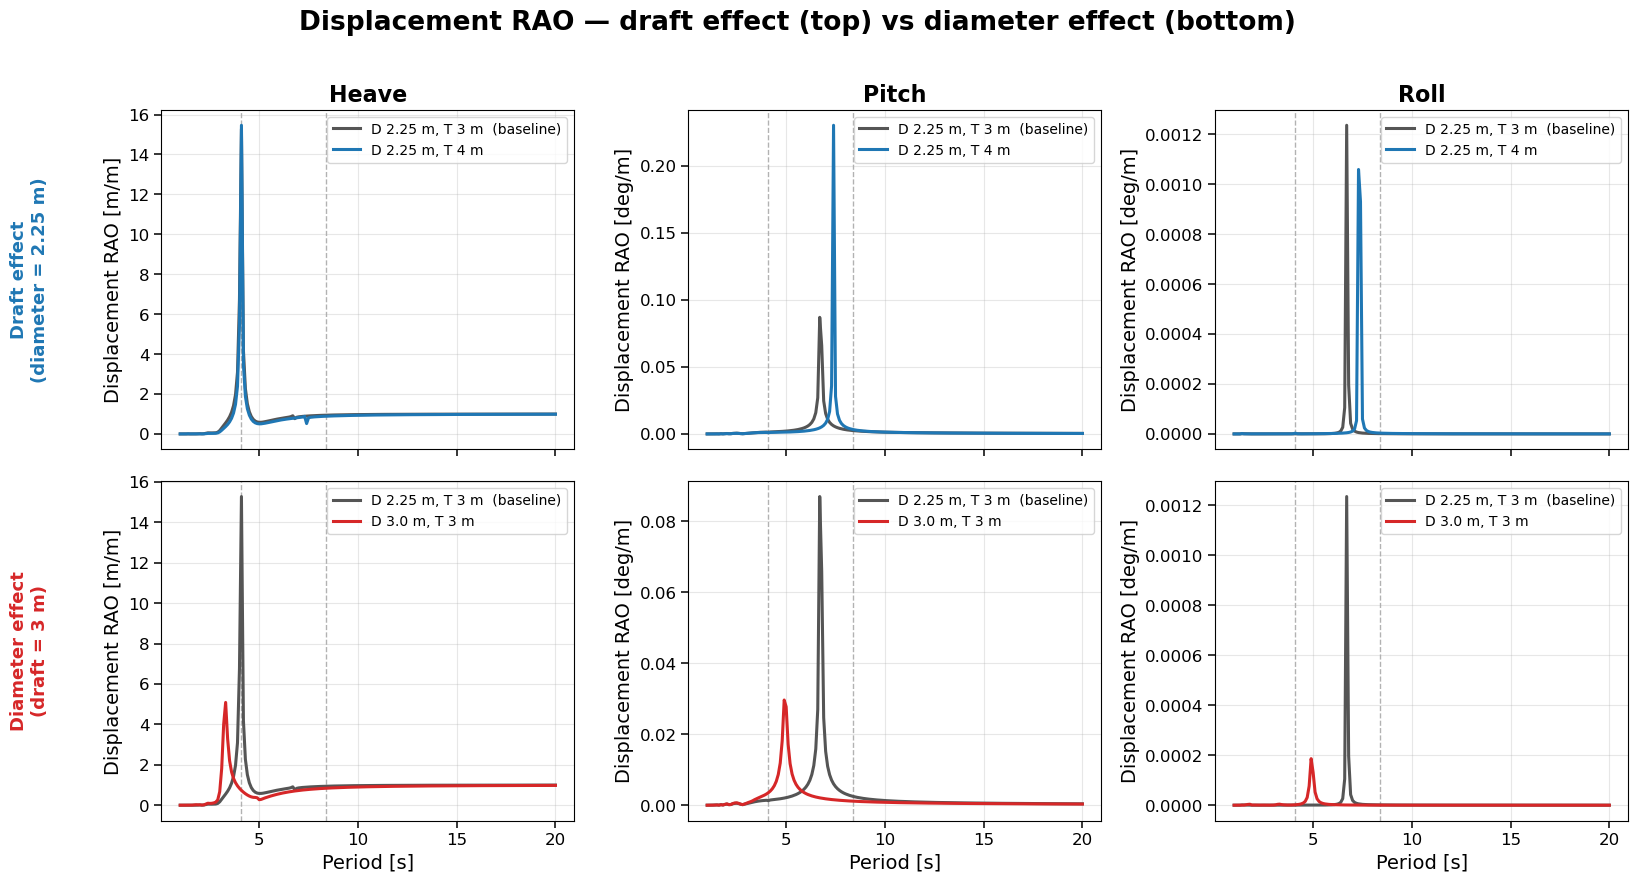

In [5]:
fig = plot_effect_grid("disp_rao", "A3_displacement_rao.png"); plt.show()


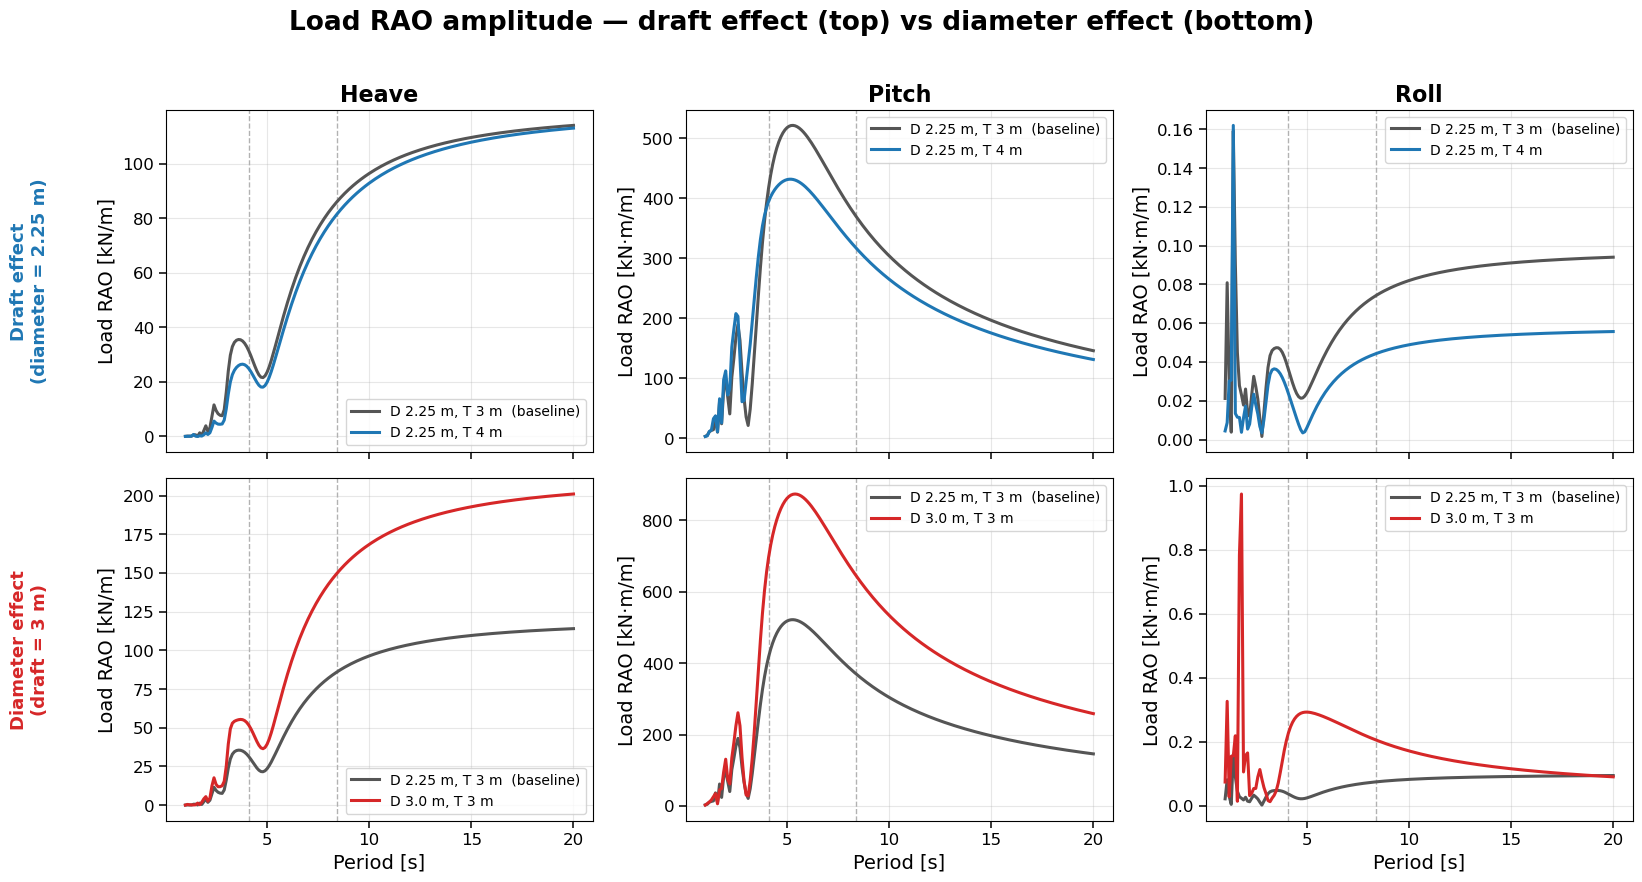

In [6]:
fig = plot_effect_grid("load_rao", "A4_load_rao.png"); plt.show()


## View B — relative influence (which parameter moves the output more?)

Percentage change of each quantity relative to the baseline, plotted against
period: blue = going from draft 3 m → 4 m, red = going from D 2.25 m → 3.0 m.
The two curves share one axis per DOF, so the **larger excursion from zero is the
more influential parameter** at that period. Values are masked where the baseline
is near zero (relative change is meaningless there).

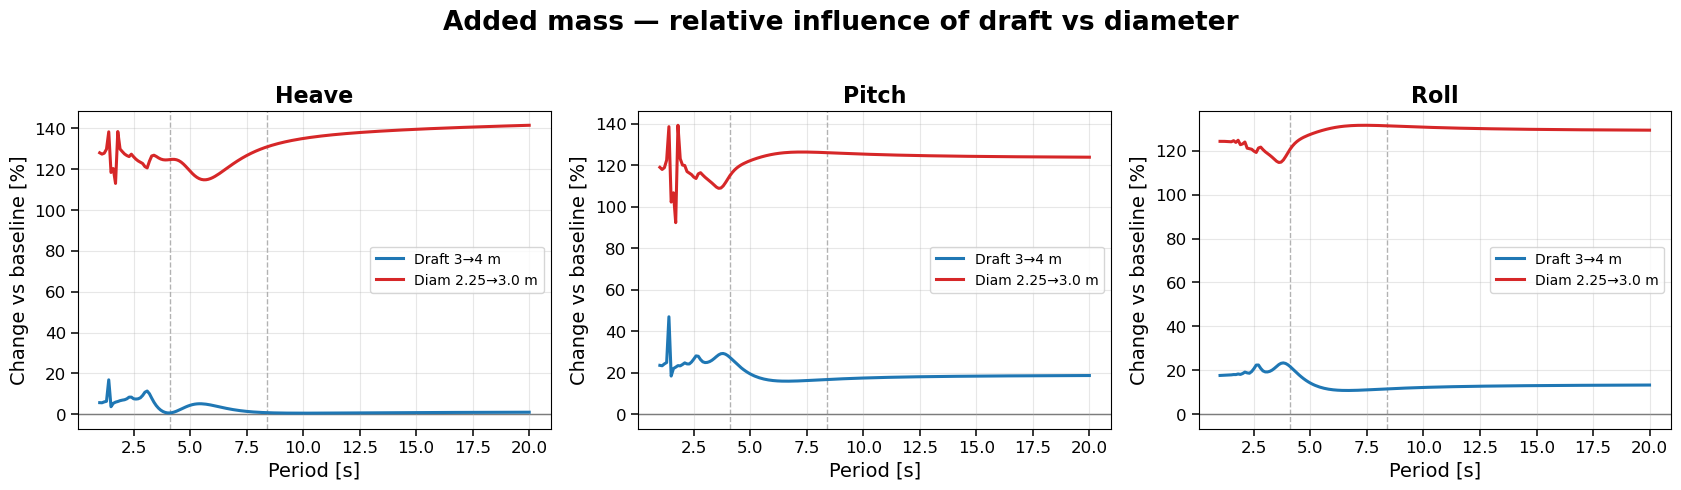

In [7]:
def relative_influence(kind, idx):
    """Return (periods, %dDraft, %dDiameter) for one DOF, masked near base~0."""
    periods, base = series("base", kind)
    _, dr = series("draft", kind)
    _, di = series("diam", kind)
    b = base[:, idx]
    floor = 0.02 * np.nanmax(np.abs(b))           # mask where baseline ~ 0
    mask = np.abs(b) >= floor
    pct_dr = np.where(mask, (dr[:, idx] - b) / b * 100.0, np.nan)
    pct_di = np.where(mask, (di[:, idx] - b) / b * 100.0, np.nan)
    return periods, pct_dr, pct_di


def plot_relative_influence(kind, fname=None):
    klabel = KINDS[kind]["label"]
    fig, axes = plt.subplots(1, len(DOFS), figsize=(17, 5), sharex=True)
    for ax, (dof_name, idx) in zip(axes, DOFS):
        periods, pct_dr, pct_di = relative_influence(kind, idx)
        ax.axhline(0, color="0.4", lw=1.0, zorder=0)
        ax.plot(periods, pct_dr, lw=2.2, color=COLOR["draft"],
                label="Draft 3\u21924 m")
        ax.plot(periods, pct_di, lw=2.2, color=COLOR["diam"],
                label="Diam 2.25\u21923.0 m")
        for T in POI_LINES:
            ax.axvline(T, color="0.5", ls="--", lw=1.0, alpha=0.6, zorder=0)
        ax.set_title(dof_name, fontweight="bold")
        ax.set_xlabel("Period [s]")
        ax.set_ylabel("Change vs baseline [%]")
        ax.grid(True, alpha=0.3)
        ax.tick_params(width=1.1, length=5)
        ax.legend(fontsize=10)
    fig.suptitle(f"{klabel} — relative influence of draft vs diameter",
                 fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    if fname:
        fig.savefig(FIG_DIR / fname, dpi=150, bbox_inches="tight")
    return fig


fig = plot_relative_influence("added_mass", "B1_rel_added_mass.png"); plt.show()


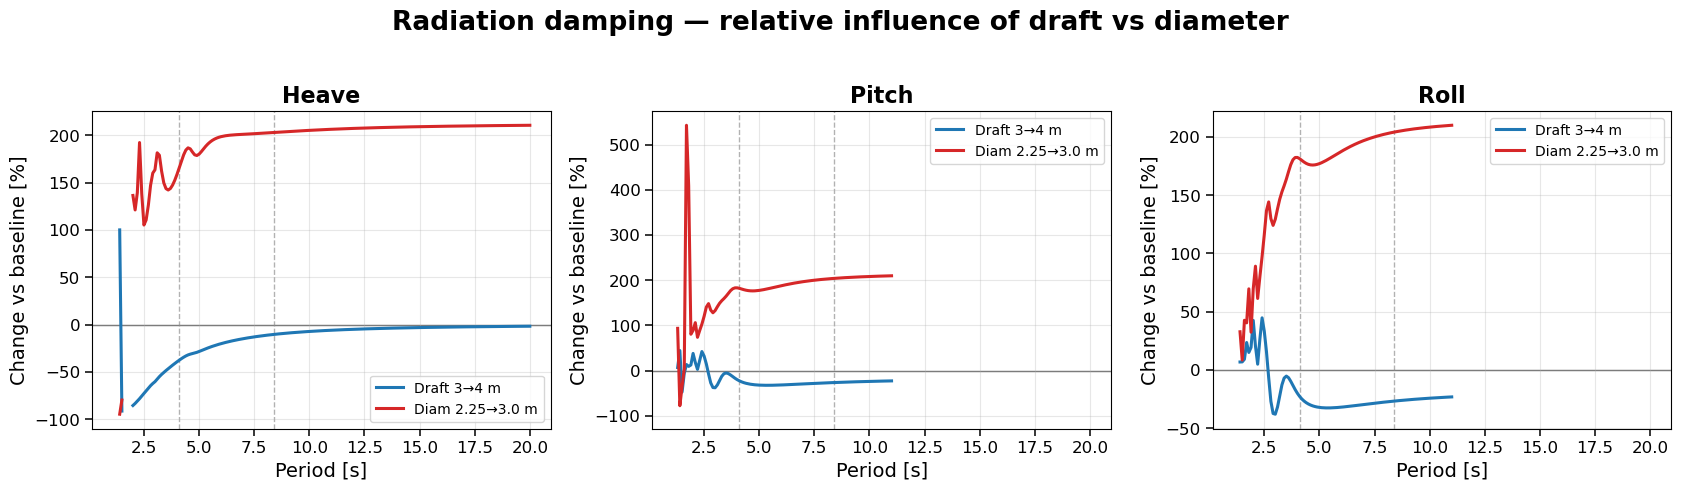

In [8]:
fig = plot_relative_influence("damping", "B2_rel_damping.png"); plt.show()


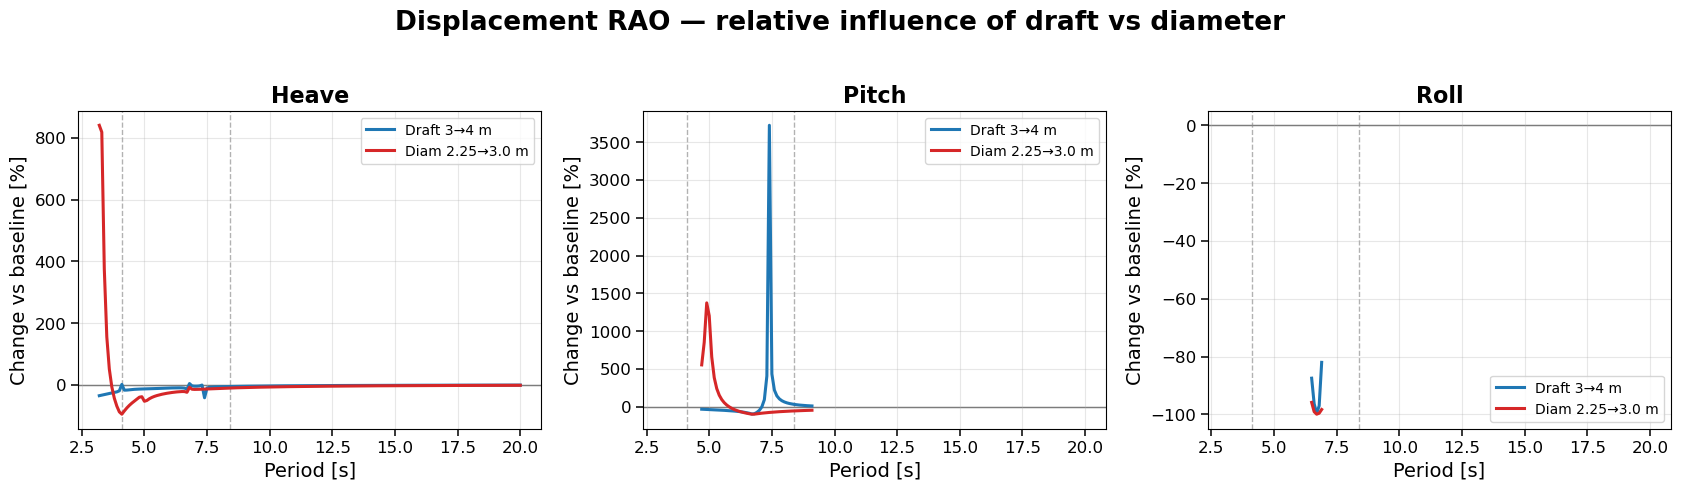

In [9]:
fig = plot_relative_influence("disp_rao", "B3_rel_displacement_rao.png"); plt.show()


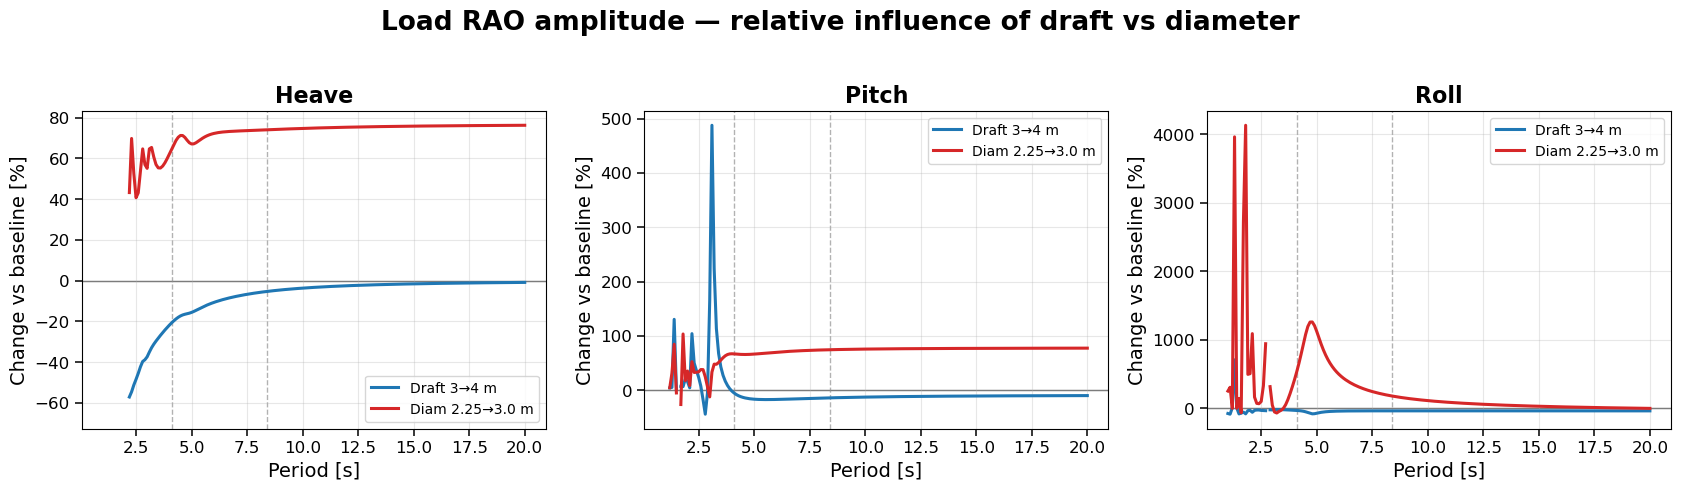

In [12]:
fig = plot_relative_influence("load_rao", "B3_rel_displacement_rao.png"); plt.show()

## View C — hydrostatic stiffness

Hydrostatic stiffness is a single value per run (no period dependence), so it is
shown as grouped bars over the three runs. Rotational terms are converted
kN·m/rad → kN·m/deg. This view makes the mechanism explicit: heave stiffness
(= ρg·waterplane area) is set by **diameter** and is unchanged by draft, whereas
the roll/pitch terms respond to **both** through the metacentric height.

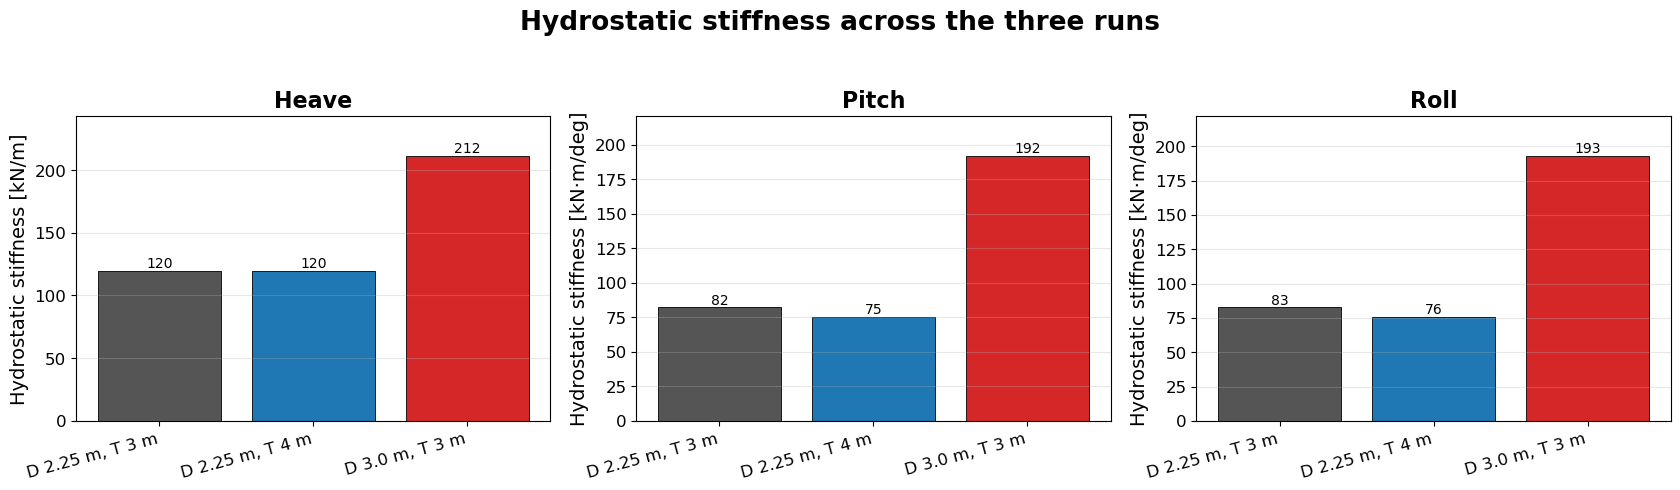

In [10]:
def plot_stiffness_bars(fname="C1_hydrostatic_stiffness.png"):
    order = ["base", "draft", "diam"]
    fig, axes = plt.subplots(1, len(DOFS), figsize=(17, 5))
    for ax, (dof_name, idx) in zip(axes, DOFS):
        vals = []
        for rk in order:
            v = read_hydrostatic_stiffness(str(RUNS[rk]["path"]))[idx]
            if idx in ROT_IDX:
                v = v / RAD2DEG                     # kN.m/rad -> kN.m/deg
            vals.append(v)
        bars = ax.bar(range(len(order)), vals,
                      color=[COLOR[k] for k in order], edgecolor="k", linewidth=0.6)
        ax.set_xticks(range(len(order)))
        ax.set_xticklabels([RUNS[k]["label"].split("  ")[0] for k in order],
                           rotation=15, ha="right")
        unit = "kN/m" if idx not in ROT_IDX else "kN\u00b7m/deg"
        ax.set_title(dof_name, fontweight="bold")
        ax.set_ylabel(f"Hydrostatic stiffness [{unit}]")
        ax.grid(True, axis="y", alpha=0.3)
        for b, v in zip(bars, vals):
            ax.annotate(f"{v:,.0f}", (b.get_x() + b.get_width() / 2, v),
                        ha="center", va="bottom", fontsize=10)
        ax.margins(y=0.15)
    fig.suptitle("Hydrostatic stiffness across the three runs", fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    fig.savefig(FIG_DIR / fname, dpi=150, bbox_inches="tight")
    return fig


fig = plot_stiffness_bars(); plt.show()


## View D — quantitative summary

Two tables. First, the indicative period proxy (displacement-RAO peak, *not* a
true natural period — see caveat). Second, a compact "which parameter dominates"
table: the median absolute %-change across the period range for each effect, per
quantity and DOF, with the larger one flagged.

In [11]:
# --- Table 1: displacement-RAO peak period (proxy only) -----------------------
rows = []
for rk in ["base", "draft", "diam"]:
    periods, ampl = series(rk, "disp_rao")
    row = {"Run": RUNS[rk]["label"]}
    for dof_name, idx in DOFS:
        k = int(np.argmax(ampl[:, idx]))
        edge = (k == 0 or k == len(periods) - 1)
        row[dof_name] = f"{periods[k]:.2f}" + ("*" if edge else "")
    rows.append(row)
peak_tbl = pd.DataFrame(rows).set_index("Run")
print("Displacement-RAO peak period [s]  (* = at grid edge; proxy, not a true "
      "natural period)\n")
print(peak_tbl.to_string(), "\n")

# --- Table 2: median |%change| per effect, per quantity/DOF -------------------
rows = []
for kind in ["added_mass", "damping", "disp_rao", "load_rao"]:
    for dof_name, idx in DOFS:
        _, pct_dr, pct_di = relative_influence(kind, idx)
        md_dr = np.nanmedian(np.abs(pct_dr))
        md_di = np.nanmedian(np.abs(pct_di))
        dominant = "Draft" if md_dr > md_di else "Diameter"
        rows.append({
            "Quantity": KINDS[kind]["label"], "DOF": dof_name,
            "|%d| draft": round(md_dr, 1), "|%d| diam": round(md_di, 1),
            "Dominant": dominant,
        })
dom_tbl = pd.DataFrame(rows)
print("Median |% change vs baseline| over the period range "
      "(larger = more influential):\n")
print(dom_tbl.to_string(index=False))


Displacement-RAO peak period [s]  (* = at grid edge; proxy, not a true natural period)

                            Heave Pitch  Roll
Run                                          
D 2.25 m, T 3 m  (baseline)  4.10  6.70  6.70
D 2.25 m, T 4 m              4.10  7.40  7.30
D 3.0 m, T 3 m               3.30  4.90  4.90 

Median |% change vs baseline| over the period range (larger = more influential):

          Quantity   DOF  |%d| draft  |%d| diam Dominant
        Added mass Heave         0.9      136.1 Diameter
        Added mass Pitch        18.3      124.2 Diameter
        Added mass  Roll        13.0      129.7 Diameter
 Radiation damping Heave         6.2      206.3 Diameter
 Radiation damping Pitch        26.8      190.7 Diameter
 Radiation damping  Roll        26.6      189.5 Diameter
  Displacement RAO Heave         2.6        5.1 Diameter
  Displacement RAO Pitch        48.9       69.1 Diameter
  Displacement RAO  Roll        96.3       99.1 Diameter
Load RAO amplitude Heave    